In [0]:
"""
Set up Spark access to Azure Data Lake Storage (ADLS) 
using the account access key and list all files in the lakehouse container 
to verify the connection.
"""

spark.conf.set(
    "fs.azure.account.key.projectlinkedinjobs.dfs.core.windows.net",
    "<access-key>"
)

display(
    dbutils.fs.ls("abfss://lakehouse@projectlinkedinjobs.dfs.core.windows.net/gold/")
)


path,name,size,modificationTime
abfss://lakehouse@projectlinkedinjobs.dfs.core.windows.net/gold/curated_postings/,curated_postings/,0,1763214523000
abfss://lakehouse@projectlinkedinjobs.dfs.core.windows.net/gold/feature_v2/,feature_v2/,0,1763572763000
abfss://lakehouse@projectlinkedinjobs.dfs.core.windows.net/gold/linkedin_feature_v2/,linkedin_feature_v2/,0,1763574160000
abfss://lakehouse@projectlinkedinjobs.dfs.core.windows.net/gold/linkedin_features_v1/,linkedin_features_v1/,0,1763570940000


In [0]:
# Base path
BASE_PATH = "abfss://lakehouse@projectlinkedinjobs.dfs.core.windows.net/gold/linkedin_feature_v2"

# Load Delta folders
train_df = spark.read.format("delta").load(f"{BASE_PATH}/combined_train")
val_df   = spark.read.format("delta").load(f"{BASE_PATH}/combined_val")
test_df  = spark.read.format("delta").load(f"{BASE_PATH}/combined_test")

# Check rows and schema
print("Train rows:", train_df.count())
print("Val rows:  ", val_df.count())
print("Test rows: ", test_df.count())

train_df.printSchema()


Train rows: 130134
Val rows:   27777
Test rows:  27761
root
 |-- company: string (nullable = true)
 |-- search_country: string (nullable = true)
 |-- job_level: string (nullable = true)
 |-- job_type: string (nullable = true)
 |-- job_skills: string (nullable = true)
 |-- job_summary: string (nullable = true)
 |-- job_role: string (nullable = true)
 |-- label: double (nullable = true)
 |-- raw_text: string (nullable = true)
 |-- clean_text: string (nullable = true)
 |-- text_length_words: integer (nullable = true)
 |-- text_length_chars: integer (nullable = true)
 |-- sentiment_pos: double (nullable = true)
 |-- sentiment_neu: double (nullable = true)
 |-- sentiment_neg: double (nullable = true)
 |-- sentiment_compound: double (nullable = true)
 |-- words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- raw_features: vector (nullable = true)
 |-- tfidf_features: vec

In [0]:
train_df.groupBy("job_role").count().orderBy("count", ascending=False).show()


+--------------------+-----+
|            job_role|count|
+--------------------+-----+
|customer service ...| 7102|
|  sales associate ft| 5166|
|       store manager| 4427|
|       shift manager| 4256|
|          accountant| 4108|
|   assistant manager| 4046|
|first year tax pr...| 3732|
|  sales associate pt| 3444|
|    registered nurse| 3236|
|   account executive| 2177|
|hourly supervisor...| 2077|
|                host| 2018|
|travel allied hea...| 2018|
|     project manager| 1942|
|  restaurant manager| 1718|
| electrical engineer| 1612|
|   software engineer| 1603|
| registered nurse rn| 1577|
| executive assistant| 1560|
|hourly supervisor...| 1532|
+--------------------+-----+
only showing top 20 rows


In [0]:
train_df.select("text_length_words", "text_length_chars").describe().show()


+-------+------------------+------------------+
|summary| text_length_words| text_length_chars|
+-------+------------------+------------------+
|  count|            130134|            130134|
|   mean|283.31660442313307|1979.9547850676995|
| stddev| 307.8402139988681|2104.3016981672463|
|    min|                 2|                18|
|    max|              3171|             20791|
+-------+------------------+------------------+



In [0]:
train_df.select("sentiment_pos", "sentiment_neg", "sentiment_neu").describe().show()


+-------+-------------------+--------------------+------------------+
|summary|      sentiment_pos|       sentiment_neg|     sentiment_neu|
+-------+-------------------+--------------------+------------------+
|  count|             130134|              130134|            130134|
|   mean|0.16309226643306143|0.022358814760170317|0.8145476278297744|
| stddev|0.08357354677353802| 0.03207331394218879|0.0927363345360162|
|    min|                0.0|                 0.0|             0.255|
|    max|              0.656|               0.454|               1.0|
+-------+-------------------+--------------------+------------------+



In [0]:
train_df.select("readability_score", "subjectivity", "lexical_diversity").describe().show()


+-------+-------------------+-------------------+--------------------+
|summary|  readability_score|       subjectivity|   lexical_diversity|
+-------+-------------------+-------------------+--------------------+
|  count|             130134|             130134|              130134|
|   mean| -271.2673122292017|  0.341089486681237|  0.6862828232941036|
| stddev|  294.8726061490399|0.17874961508392379| 0.19269209596225653|
|    min|-3171.4588552507093|                0.0|0.049204052098408106|
|    max|  81.13103448275862|                1.0|                 1.0|
+-------+-------------------+-------------------+--------------------+



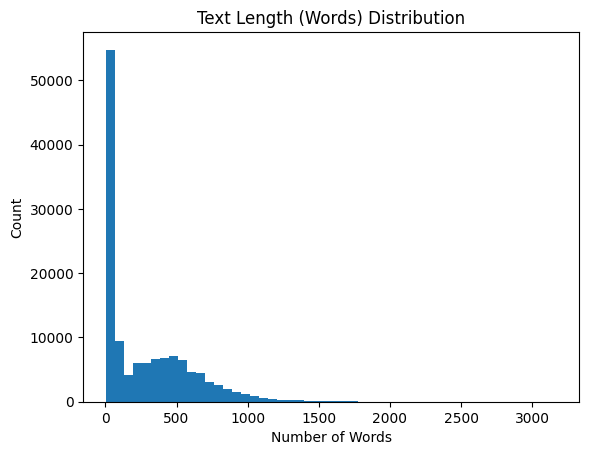

In [0]:
import matplotlib.pyplot as plt

plt.hist(train_df.select("text_length_words").rdd.flatMap(lambda x: x).collect(), bins=50)
plt.title("Text Length (Words) Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()


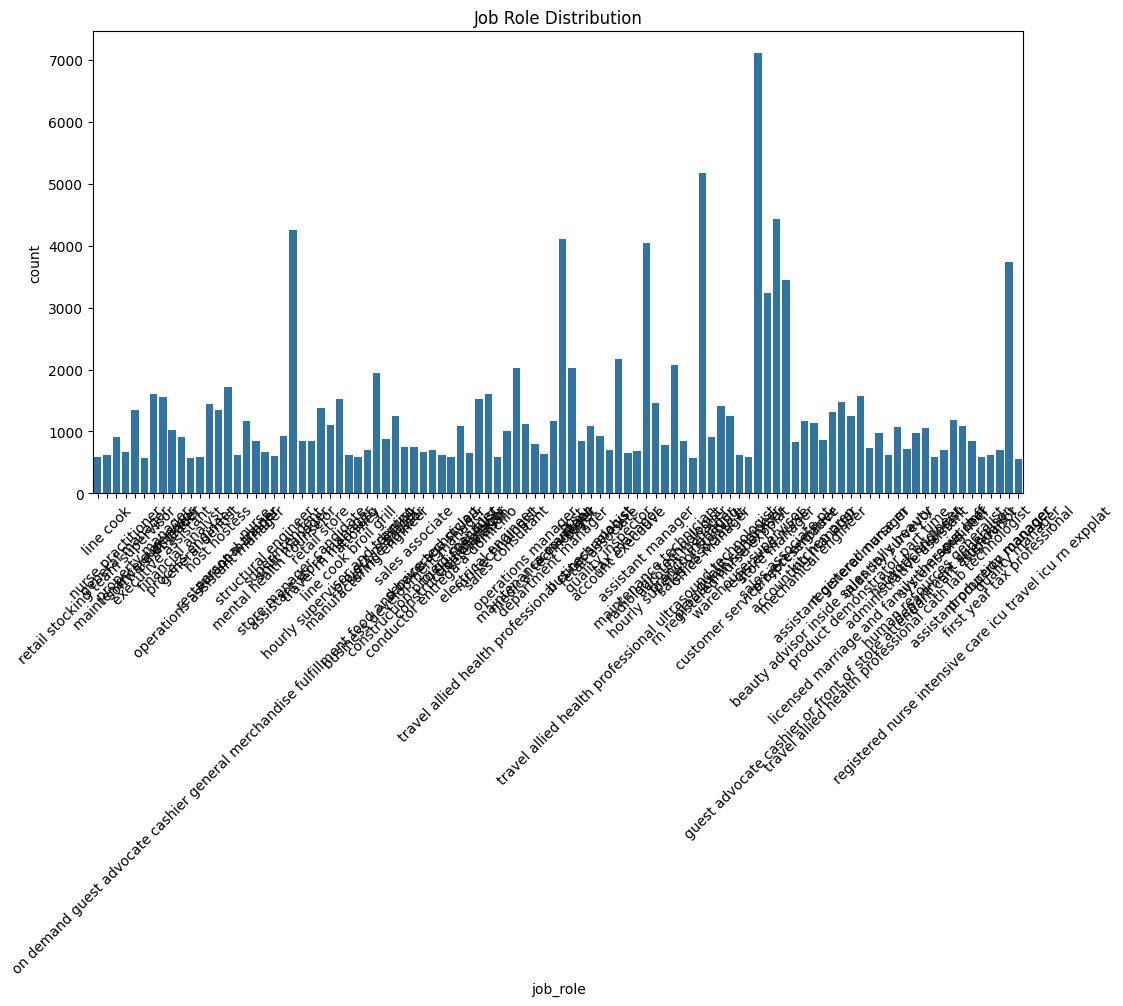

In [0]:
import pandas as pd
import seaborn as sns

role_counts = train_df.groupBy("job_role").count().toPandas()
plt.figure(figsize=(12,6))
sns.barplot(x="job_role", y="count", data=role_counts)
plt.xticks(rotation=45)
plt.title("Job Role Distribution")
plt.show()


In [0]:
# Train Random Forest on TF-IDF features
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="label",       # numeric version of job_role
    featuresCol="tfidf_features",
    numTrees=50
)

model = rf.fit(train_df)
print("Model trained successfully.")


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

Model trained successfully.


In [0]:
train_preds = model.transform(train_df)
train_preds.select("job_role", "label", "prediction").show(10, truncate=False)


+-------------------------------+-----+----------+
|job_role                       |label|prediction|
+-------------------------------+-----+----------+
|customer service representative|0.0  |0.0       |
|network engineer               |46.0 |0.0       |
|accountant                     |4.0  |4.0       |
|personal trainer               |85.0 |0.0       |
|personal trainer               |85.0 |85.0      |
|personal trainer               |85.0 |0.0       |
|personal trainer               |85.0 |0.0       |
|personal trainer               |85.0 |85.0      |
|personal trainer               |85.0 |85.0      |
|personal trainer               |85.0 |0.0       |
+-------------------------------+-----+----------+
only showing top 10 rows


In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction"
)

train_accuracy = evaluator.evaluate(train_preds, {evaluator.metricName: "accuracy"})
train_f1 = evaluator.evaluate(train_preds, {evaluator.metricName: "f1"})
train_precision = evaluator.evaluate(train_preds, {evaluator.metricName: "weightedPrecision"})
train_recall = evaluator.evaluate(train_preds, {evaluator.metricName: "weightedRecall"})

print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Training F1 Score: {train_f1:.3f}")
print(f"Training Precision: {train_precision:.3f}")
print(f"Training Recall: {train_recall:.3f}")


Training Accuracy: 0.321
Training F1 Score: 0.248
Training Precision: 0.458
Training Recall: 0.321


In [0]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.feature import StringIndexer, IndexToString

# Train Random Forest
rf = RandomForestClassifier(labelCol="label", featuresCol="tfidf_features", numTrees=50)
model = rf.fit(train_df)
print("Model trained successfully.")


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

Model trained successfully.


In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy = evaluator.evaluate(train_preds, {evaluator.metricName: "accuracy"})
f1 = evaluator.evaluate(train_preds, {evaluator.metricName: "f1"})

print(f"Training Accuracy: {accuracy:.3f}")
print(f"Training F1 Score: {f1:.3f}")


Training Accuracy: 0.321
Training F1 Score: 0.248


In [0]:
from pyspark.ml.feature import VectorAssembler

# Choose features for modeling
feature_cols = [
    "tfidf_features",         # TF-IDF vector
    # For bert_embedding, we need to convert array -> vector
    "sentiment_pos",
    "sentiment_neu",
    "sentiment_neg",
    "sentiment_compound",
    "readability_score",
    "subjectivity",
    "text_length_words",
    "text_length_chars",
    "avg_word_length",
    "lexical_diversity"
]

# If using bert_embedding, convert array<float> -> DenseVector first
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.sql.functions import udf
import numpy as np

def array_to_vector(arr):
    return Vectors.dense(arr) if arr is not None else None

array_to_vector_udf = udf(array_to_vector, VectorUDT())
train_df = train_df.withColumn("bert_vector", array_to_vector_udf("bert_embedding"))
test_df = test_df.withColumn("bert_vector", array_to_vector_udf("bert_embedding"))

# Include bert_vector in features
feature_cols.append("bert_vector")

# Assemble all features into a single vector
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
train_df = assembler.transform(train_df)
test_df = assembler.transform(test_df)


In [0]:
preds = model.transform(train_df)  # training metrics

from pyspark.ml.feature import IndexToString
label_converter = IndexToString(inputCol="prediction", outputCol="predicted_job_role")

from pyspark.ml.evaluation import MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
accuracy = evaluator.evaluate(preds, {evaluator.metricName: "accuracy"})
f1 = evaluator.evaluate(preds, {evaluator.metricName: "f1"})
print(f"Training Accuracy: {accuracy:.3f}, F1 Score: {f1:.3f}")


Training Accuracy: 0.356, F1 Score: 0.273


In [0]:
from pyspark.ml.classification import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=50)
model = rf.fit(train_df)

# Predict on training data
preds = model.transform(train_df)


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy = evaluator.evaluate(preds, {evaluator.metricName: "accuracy"})
f1 = evaluator.evaluate(preds, {evaluator.metricName: "f1"})

print(f"Training Accuracy: {accuracy:.3f}")
print(f"Training F1 Score: {f1:.3f}")


Training Accuracy: 0.356
Training F1 Score: 0.273


In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

metrics = ["accuracy", "f1", "weightedPrecision", "weightedRecall"]

for metric in metrics:
    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric
    )
    score = evaluator.evaluate(preds)
    print(f"{metric.capitalize()}: {score:.3f}")


Accuracy: 0.356
F1: 0.273
Weightedprecision: 0.459
Weightedrecall: 0.356


In [0]:
from pyspark.sql.functions import col

per_class = preds.groupBy("label").agg(
    {"prediction": "count"}
).withColumnRenamed("count(prediction)", "support")



In [0]:
import pandas as pd
#checking feature importance
rf_model = model  
feature_importances = rf_model.featureImportances.toArray()

feat_df = pd.DataFrame({
    "feature": ["feature_"+str(i) for i in range(len(feature_importances))],
    "importance": feature_importances
}).sort_values(by="importance", ascending=False)

print(feat_df.head(20))


           feature  importance
479    feature_479    0.022601
447    feature_447    0.018368
2032  feature_2032    0.016186
603    feature_603    0.014581
271    feature_271    0.013901
5248  feature_5248    0.013698
5147  feature_5147    0.012899
1386  feature_1386    0.012844
929    feature_929    0.012460
1005  feature_1005    0.011977
84      feature_84    0.011658
1435  feature_1435    0.010659
378    feature_378    0.010577
2194  feature_2194    0.010175
423    feature_423    0.009657
478    feature_478    0.009101
355    feature_355    0.008610
5257  feature_5257    0.008579
5087  feature_5087    0.008573
265    feature_265    0.008401


In [0]:
#error analysis
misclassified = preds.filter(col("label") != col("prediction"))
misclassified.select("job_role", "prediction", "raw_text").show(10, truncate=100)


+----------------------------+----------+----------------------------------------------------------------------------------------------------+
|                    job_role|prediction|                                                                                            raw_text|
+----------------------------+----------+----------------------------------------------------------------------------------------------------+
|                  supervisor|       0.0|description ability to supervise any area of the distribution center or production reviews work l...|
|business development manager|       0.0|job summary: the primary responsibility of the business development manager is to prospect, grow,...|
|         executive assistant|       4.0|job title: executive assistant – transit police location: austin, tx 78702 duration: 06 months wi...|
|            personal trainer|       0.0|full,ime part,ime location 15301 ventura blvd. sherman oaks ca 91403 job summary the fitness coac...|

In [0]:
from pyspark.ml.feature import VectorAssembler

numeric_cols = [
    "text_length_words", "text_length_chars",
    "sentiment_pos", "sentiment_neu", "sentiment_neg", "sentiment_compound",
    "readability_score", "subjectivity", "avg_word_length", "lexical_diversity"
]

assembler = VectorAssembler(
    inputCols=numeric_cols + ["tfidf_features"],  
    outputCol="lr_features"
)

train_data = assembler.transform(train_df)


In [0]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="lr_features",
    labelCol="label",
    maxIter=100,
    family="multinomial"
)

model = lr.fit(train_data)


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

In [0]:
preds = model.transform(train_data)

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy = evaluator.evaluate(preds, {evaluator.metricName: "accuracy"})
f1 = evaluator.evaluate(preds, {evaluator.metricName: "f1"})
precision = evaluator.evaluate(preds, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(preds, {evaluator.metricName: "weightedRecall"})

print(f"Accuracy: {accuracy:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")


Accuracy: 0.957
F1 Score: 0.959
Precision: 0.967
Recall: 0.957


In [0]:
# See class distribution for class imbalance
train_df.groupBy("job_role").count().orderBy("count", ascending=False).show()


+--------------------+-----+
|            job_role|count|
+--------------------+-----+
|customer service ...| 7102|
|  sales associate ft| 5166|
|       store manager| 4427|
|       shift manager| 4256|
|          accountant| 4108|
|   assistant manager| 4046|
|first year tax pr...| 3732|
|  sales associate pt| 3444|
|    registered nurse| 3236|
|   account executive| 2177|
|hourly supervisor...| 2077|
|travel allied hea...| 2018|
|                host| 2018|
|     project manager| 1942|
|  restaurant manager| 1718|
| electrical engineer| 1612|
|   software engineer| 1603|
| registered nurse rn| 1577|
| executive assistant| 1560|
|hourly supervisor...| 1532|
+--------------------+-----+
only showing top 20 rows


In [0]:
# Assemble features for test set
test_data = assembler.transform(test_df)  # use same assembler as train

# Predict
test_preds = model.transform(test_data)

# Evaluate metrics
accuracy = evaluator.evaluate(test_preds, {evaluator.metricName: "accuracy"})
f1 = evaluator.evaluate(test_preds, {evaluator.metricName: "f1"})
precision = evaluator.evaluate(test_preds, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(test_preds, {evaluator.metricName: "weightedRecall"})

print(f"Test Accuracy: {accuracy:.3f}")
print(f"Test F1 Score: {f1:.3f}")
print(f"Test Precision: {precision:.3f}")
print(f"Test Recall: {recall:.3f}")


Test Accuracy: 0.864
Test F1 Score: 0.866
Test Precision: 0.873
Test Recall: 0.864
